In [18]:
# Affichage du résumé détaillé de l'architecture du modèle

# Affiche les couches du réseau, leurs dimensions de sortie
# ainsi que le nombre de paramètres entraînables et non entraînables
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10, 64)            17664     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 32)                1056      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 31169 (121.75 KB)
Trainable params: 31169 (121.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [3]:
# Importation des bibliothèques nécessaires au projet

# Manipulation et analyse des données tabulaires
import pandas as pd

# Calcul scientifique et opérations sur les tableaux numériques
import numpy as np

# Création de graphiques et visualisations
import matplotlib.pyplot as plt

# Visualisations statistiques avancées
import seaborn as sns

# Gestion et masquage des messages d'avertissement
import warnings

# Accès aux fonctionnalités du système Python
import sys

# Désactivation des warnings pour un affichage plus propre
warnings.filterwarnings("ignore")

# Ajout du dossier src au chemin de recherche Python
# Permet d'importer les modules personnalisés du projet
sys.path.append("../src")

# Import des fonctions de prétraitement des données
from preprocessing import scale_data, create_sequences

# Import de la fonction de construction du modèle LSTM
from model import build_lstm_model

# Import de la fonction d'entraînement du modèle
from train import train_model

# Import de la fonction d'évaluation du modèle
from evaluate import evaluate_model

# Import de l'outil de conversion du modèle pour TinyML
from eloquent_tensorflow import convert_model

# Import de TensorFlow
import tensorflow as tf

# Import de l'outil permettant de générer un schéma de l'architecture du modèle
from tensorflow.keras.utils import plot_model

# Import de la fonction de séparation des données en train et test
from sklearn.model_selection import train_test_split

In [4]:
# Chargement du dataset contenant les données de consommation de carburant

# Lecture du fichier CSV
data = pd.read_csv("../data/FuelConsumption.csv")

# Affichage des dimensions du dataset (nombre de lignes et de colonnes)
print("Shape du dataset :", data.shape)

# Affichage des cinq premières lignes pour vérifier le contenu des données
data.head()

Shape du dataset : (1067, 13)


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [5]:
# Affichage des informations générales sur le dataset

# Présente les colonnes du dataset, leurs types de données,
# le nombre de valeurs non nulles ainsi que l'utilisation mémoire
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [6]:
# Affichage des statistiques descriptives du dataset

# Calcule les principales statistiques des variables numériques :
# nombre d'observations, moyenne, écart-type, minimum,
# quartiles (25%, 50%, 75%) et maximum
data.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [7]:
# Nettoyage des données

# Suppression des espaces inutiles au début et à la fin des noms de colonnes
data.columns = data.columns.str.strip()

# Suppression des lignes contenant des valeurs manquantes
data.dropna(inplace=True)

# Suppression des lignes dupliquées
data.drop_duplicates(inplace=True)

# Affichage des dimensions du dataset après nettoyage
print("Shape après nettoyage :", data.shape)

Shape après nettoyage : (1067, 13)


In [8]:
# Affichage de la liste des colonnes du dataset

# Conversion des noms de colonnes en liste Python puis affichage
print(data.columns.tolist())

['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS', 'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS']


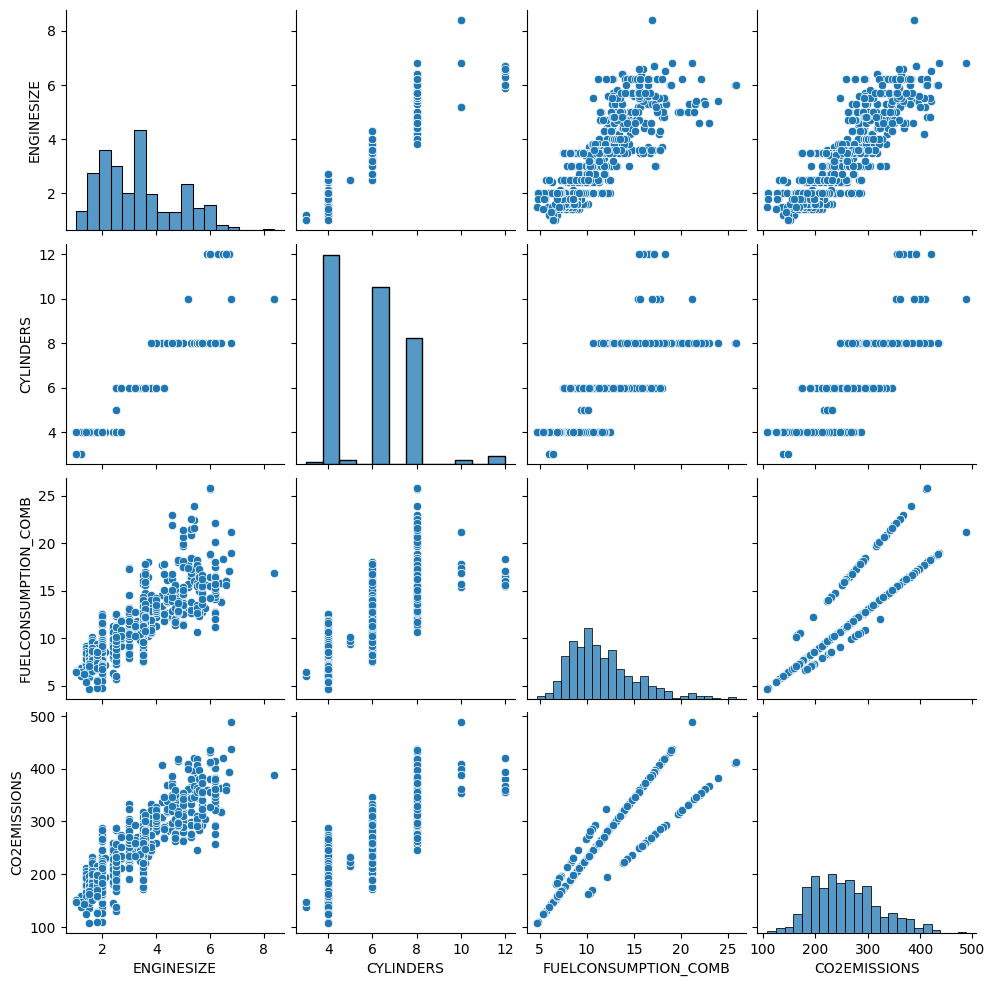

In [9]:
# Création d'un pairplot pour visualiser les relations entre les variables principales

# Affichage des relations deux à deux entre les variables sélectionnées
sns.pairplot(
    data[
        [
            'ENGINESIZE',
            'CYLINDERS',
            'FUELCONSUMPTION_COMB',
            'CO2EMISSIONS'
        ]
    ]
)

# Sauvegarde de la figure au format PNG avec une résolution élevée
plt.savefig(
    "../figures/pairplot.png",
    dpi=300,
    bbox_inches='tight'
)

# Affichage du graphique
plt.show()

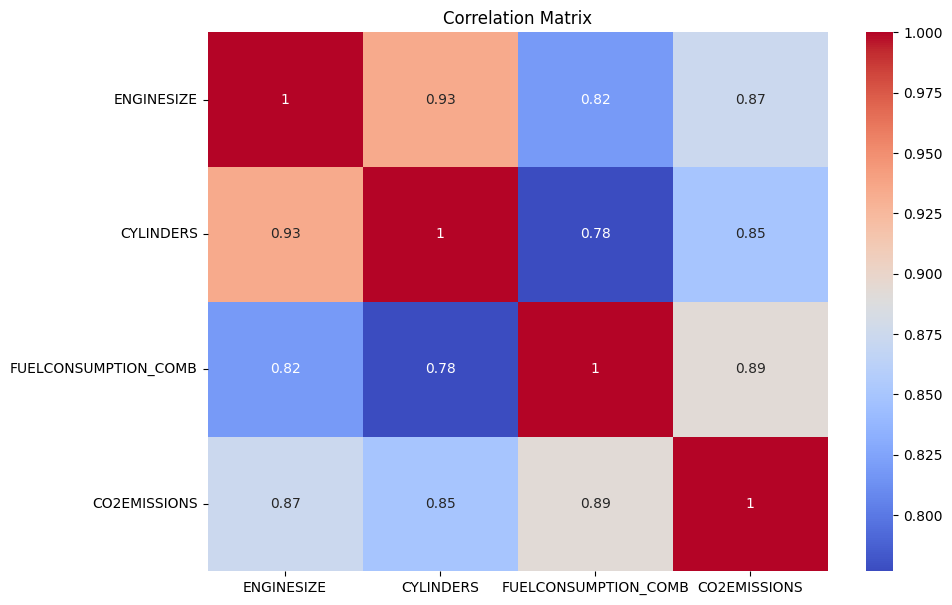

In [10]:
# Calcul de la matrice de corrélation entre les variables sélectionnées

corr = data[
    [
        'ENGINESIZE',
        'CYLINDERS',
        'FUELCONSUMPTION_COMB',
        'CO2EMISSIONS'
    ]
].corr()

# Création d'une figure pour afficher la matrice de corrélation
plt.figure(figsize=(10,7))

# Affichage de la heatmap représentant les coefficients de corrélation
sns.heatmap(
    corr,

    # Affichage des valeurs numériques dans chaque cellule
    annot=True,

    # Palette de couleurs mettant en évidence les corrélations positives et négatives
    cmap='coolwarm'
)

# Ajout du titre du graphique
plt.title("Correlation Matrix")

# Sauvegarde de la figure dans le dossier figures
plt.savefig(
    "../figures/heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

# Affichage de la figure
plt.show()

In [11]:
# Sélection des variables d'intérêt pour le modèle

# On extrait uniquement les colonnes pertinentes du dataset
features = data[
    [
        'ENGINESIZE',
        'CYLINDERS',
        'CO2EMISSIONS',
        'FUELCONSUMPTION_COMB'
    ]
]

# Affichage des premières lignes pour vérifier la sélection
features.head()

,ENGINESIZE,CYLINDERS,CO2EMISSIONS,FUELCONSUMPTION_COMB
0,2.0,4,196,8.5
1,2.4,4,221,9.6
2,1.5,4,136,5.9
3,3.5,6,255,11.1
4,3.5,6,244,10.6


In [12]:
# Normalisation (scaling) des variables sélectionnées

# Application d'une transformation de mise à l'échelle des données
# (ex: MinMaxScaler ou StandardScaler selon implémentation de scale_data)
data_scaled, scaler = scale_data(features)

# Affichage de la forme du dataset après normalisation
print(data_scaled.shape)

(1067, 4)


In [ ]:
# Création des séquences pour l'entraînement du modèle

# On transforme les données en séries temporelles supervisées
# Chaque échantillon X contient 10 pas de temps consécutifs
# et y correspond à la valeur cible à prédire
X, y = create_sequences(data_scaled, 10)

# Affichage des dimensions des données générées
# print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (1057, 10, 4)
Shape y : (1057,)


In [ ]:
# Séparation des données en ensemble d'entraînement et de test

# On divise les données pour évaluer correctement la performance du modèle
# test_size=0.2 signifie que 20% des données sont utilisées pour le test
# random_state=42 garantit la reproductibilité des résultats
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Affichage des dimensions des ensembles d'entraînement et de test
# print("Train :", X_train.shape)
print("Test :", X_test.shape)

Train : (845, 10, 4)
Test : (212, 10, 4)


In [15]:
# Construction du modèle LSTM

# Création du modèle en utilisant la fonction personnalisée build_lstm_model
# L'entrée du modèle est définie par la forme des séquences (timesteps, features)
model = build_lstm_model(
    (X.shape[1], X.shape[2])
)

# Affichage de l'architecture du modèle
# Cette commande montre les couches, les dimensions de sortie et le nombre de paramètres
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10, 64)            17664     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 32)                1056      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 31169 (121.75 KB)
Trainable params: 31169 (121.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:
# Affichage du résumé détaillé de l'architecture du modèle

# Affiche les couches du réseau, leurs dimensions de sortie
# ainsi que le nombre de paramètres entraînables et non entraînables
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 10, 64)            17664     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense (Dense)               (None, 32)                1056      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 31169 (121.75 KB)
Trainable params: 31169 (121.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [24]:
# Entraînement du modèle

# Lancement de la phase d'entraînement du modèle LSTM
# X_train contient les séquences d'entrée
# y_train contient les valeurs cibles associées
# train_model est une fonction personnalisée qui gère l'entraînement
history = train_model(
    model,
    X_train,
    y_train
)

Epoch 1/50


22/22 [==============================] - 5s 50ms/step - loss: 0.1431 - mae: 0.1431 - val_loss: 0.1112 - val_mae: 0.1112
Epoch 2/50
22/22 [==============================] - 0s 11ms/step - loss: 0.1127 - mae: 0.1127 - val_loss: 0.1103 - val_mae: 0.1103
Epoch 3/50
22/22 [==============================] - 0s 11ms/step - loss: 0.1077 - mae: 0.1077 - val_loss: 0.1081 - val_mae: 0.1081
Epoch 4/50
22/22 [==============================] - 0s 10ms/step - loss: 0.1050 - mae: 0.1050 - val_loss: 0.1119 - val_mae: 0.1119
Epoch 5/50
22/22 [==============================] - 0s 10ms/step - loss: 0.1035 - mae: 0.1035 - val_loss: 0.1011 - val_mae: 0.1011
Epoch 6/50
22/22 [==============================] - 0s 10ms/step - loss: 0.1005 - mae: 0.1005 - val_loss: 0.1016 - val_mae: 0.1016
Epoch 7/50
22/22 [==============================] - 0s 10ms/step - loss: 0.0971 - mae: 0.0971 - val_loss: 0.0944 - val_mae: 0.0944
Epoch 8/50
22/22 [==============================] - 0s 10ms/step - loss: 0.0957 -

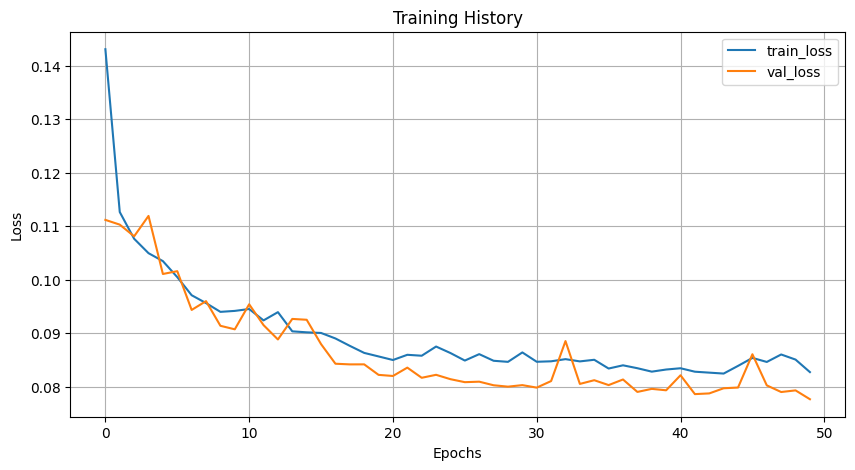

In [25]:
# Visualisation de l'historique d'entraînement

# Création de la figure
plt.figure(figsize=(10,5))

# Courbe de la loss sur les données d'entraînement
plt.plot(
    history.history['loss'],
    label='train_loss'
)

# Courbe de la loss sur les données de validation
plt.plot(
    history.history['val_loss'],
    label='val_loss'
)

# Titre du graphique
plt.title("Training History")

# Label axe X (époques)
plt.xlabel("Epochs")

# Label axe Y (valeur de la loss)
plt.ylabel("Loss")

# Affichage de la légende
plt.legend()

# Activation de la grille pour faciliter la lecture
plt.grid()

# Sauvegarde de la figure dans le dossier figures
plt.savefig(
    "../figures/history.png",
    dpi=300,
    bbox_inches='tight'
)

# Affichage du graphique
plt.show()

In [26]:
# Génération des prédictions du modèle sur les données de test

# Le modèle prédit les valeurs de sortie à partir de X_test
y_pred = model.predict(X_test)

# Affichage de la forme du tableau des prédictions
# (nombre d'échantillons, 1)
print(y_pred.shape)

7/7 [==============================] - 2s 4ms/step
(212, 1)


In [27]:
# Retour aux valeurs originales (inverse scaling)

# Conversion des tableaux en format 2D pour compatibilité avec le scaler
y_test_2d = y_test.reshape(-1, 1)
y_pred_2d = y_pred.reshape(-1, 1)

# Création de matrices factices avec le même nombre de colonnes que le dataset initial
# (nécessaire pour appliquer inverse_transform correctement)
y_test_full = np.zeros((len(y_test), 4))
y_pred_full = np.zeros((len(y_pred), 4))

# Placement de la variable cible dans la dernière colonne
# (ici CO2EMISSIONS ou variable cible choisie)
y_test_full[:, -1] = y_test_2d[:, 0]
y_pred_full[:, -1] = y_pred_2d[:, 0]

# Retour aux valeurs originales avant normalisation
y_test_inv = scaler.inverse_transform(y_test_full)[:, -1]
y_pred_inv = scaler.inverse_transform(y_pred_full)[:, -1]

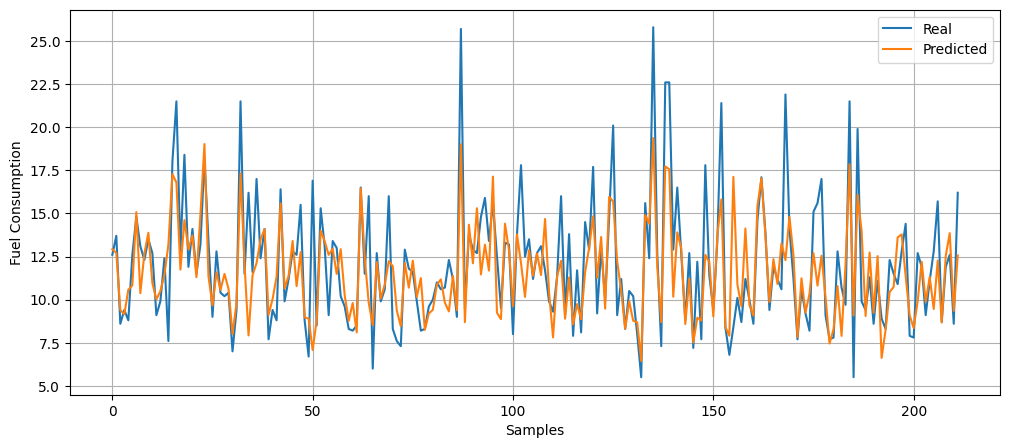

In [28]:
# Affichage des valeurs réelles vs valeurs prédites

# Création de la figure avec une taille définie
plt.figure(figsize=(12,5))

# Courbe des valeurs réelles
plt.plot(
    y_test_inv,
    label='Real'
)

# Courbe des prédictions du modèle
plt.plot(
    y_pred_inv,
    label='Predicted'
)

# Nom de l’axe X
plt.xlabel("Samples")

# Nom de l’axe Y
plt.ylabel("Fuel Consumption")

# Affichage de la légende
plt.legend()

# Ajout de la grille pour améliorer la lecture
plt.grid()

# Sauvegarde de la figure
plt.savefig(
    "../figures/predictions.png",
    dpi=300,
    bbox_inches='tight'
)

# Affichage du graphique
plt.show()

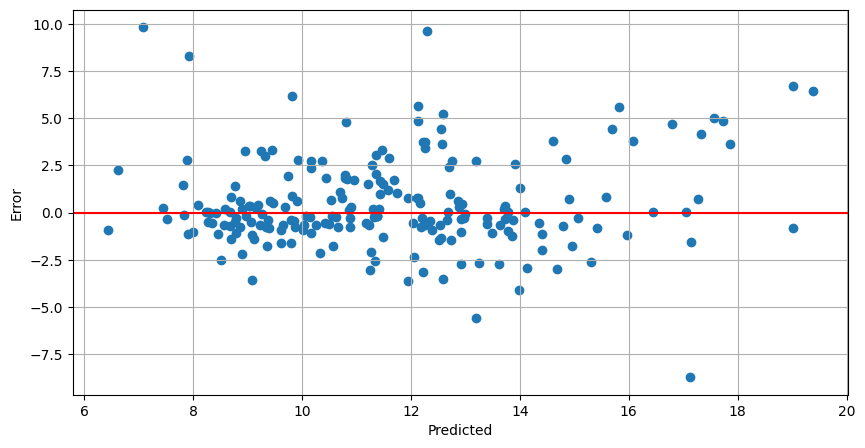

In [29]:
# Analyse des résidus (erreurs de prédiction)

# Calcul des résidus : différence entre valeurs réelles et prédites
residuals = y_test_inv - y_pred_inv

# Création de la figure
plt.figure(figsize=(10,5))

# Nuage de points : prédictions vs erreurs
plt.scatter(
    y_pred_inv,
    residuals
)

# Ligne horizontale représentant l'erreur nulle
plt.axhline(
    0,
    color='red'
)

# Nom de l’axe X
plt.xlabel("Predicted")

# Nom de l’axe Y
plt.ylabel("Error")

# Affichage de la grille
plt.grid()

# Sauvegarde de la figure
plt.savefig(
    "../figures/residuals.png",
    dpi=300,
    bbox_inches='tight'
)

# Affichage du graphique
plt.show()

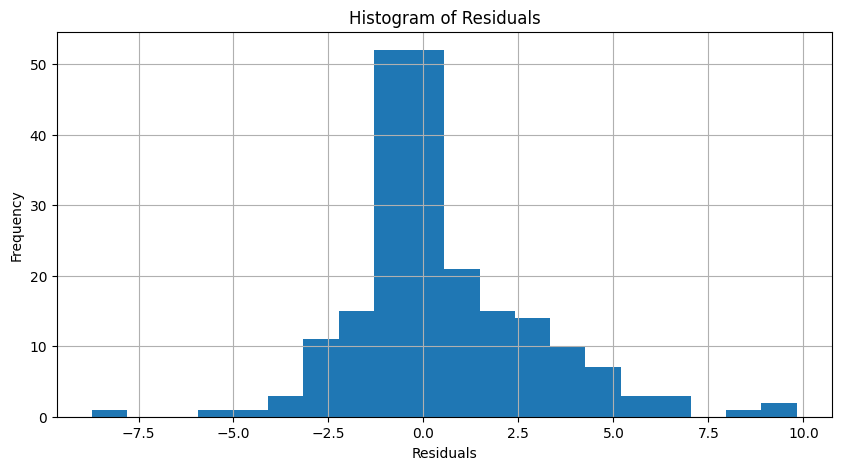

In [30]:
# Histogramme des résidus (distribution des erreurs)

# Création de la figure avec une taille définie
plt.figure(figsize=(10,5))

# Tracé de l'histogramme des résidus
# bins=20 définit le nombre de barres
plt.hist(
    residuals,
    bins=20
)

# Titre du graphique
plt.title("Histogram of Residuals")

# Label axe X
plt.xlabel("Residuals")

# Label axe Y
plt.ylabel("Frequency")

# Activation de la grille
plt.grid()

# Sauvegarde de la figure
plt.savefig(
    "../figures/residuals_histogram.png",
    dpi=300,
    bbox_inches='tight'
)

# Affichage du graphique
plt.show()

In [31]:
# Évaluation du modèle sur les données de test

# Calcul de la perte (loss) sur X_test et y_test
loss = model.evaluate(X_test, y_test)

# Affichage de la loss finale
print("Loss :", loss)

7/7 [==============================] - 0s 6ms/step - loss: 0.0795 - mae: 0.0795
Loss : [0.07947240024805069, 0.07947240024805069]


In [32]:
# Calcul des métriques d'évaluation du modèle

# La fonction evaluate_model calcule plusieurs indicateurs de performance :
# MAE  : Mean Absolute Error (erreur absolue moyenne)
# MSE  : Mean Squared Error (erreur quadratique moyenne)
# RMSE : Root Mean Squared Error (racine de MSE)
# R2   : coefficient de détermination

mae, mse, rmse, r2 = evaluate_model(
    y_test_inv,
    y_pred_inv
)

Model Evaluation
MAE  : 1.6769
MSE  : 6.0232
RMSE : 2.4542
R2   : 0.5559


In [33]:
# Sauvegarde du modèle entraîné

# Enregistrement du modèle au format H5 pour réutilisation future
model.save("../models/lstm_model.h5")

# Confirmation de la sauvegarde
print("Modèle sauvegardé")

Modèle sauvegardé


In [34]:
# Conversion du modèle vers TinyML

# Transformation du modèle Keras en code compatible microcontrôleur (C/C++)
code = convert_model(model)

# Sauvegarde du code généré dans un fichier header (.h)
with open("../tinyml/model_tinyml.h", "w") as f:
    f.write(code)

# Confirmation de l'export TinyML
print("TinyML exporté")

INFO:tensorflow:Assets written to: C:\Users\adilu\AppData\Local\Temp\tmpkzj5ftsl\assets


INFO:tensorflow:Assets written to: C:\Users\adilu\AppData\Local\Temp\tmpkzj5ftsl\assets


TinyML exporté


In [35]:
# Aperçu du code généré pour TinyML

# Affichage des 3000 premiers caractères du modèle converti
# Cela permet de vérifier la structure du code C/C++ généré
print(code[:3000])


#pragma once

#ifdef __has_attribute
#define HAVE_ATTRIBUTE(x) __has_attribute(x)
#else
#define HAVE_ATTRIBUTE(x) 0
#endif
#if HAVE_ATTRIBUTE(aligned) || (defined(__GNUC__) && !defined(__clang__))
#define DATA_ALIGN_ATTRIBUTE __attribute__((aligned(4)))
#else
#define DATA_ALIGN_ATTRIBUTE
#endif

// automatically configure network
#define TF_NUM_INPUTS 40
#define TF_NUM_OUTPUTS 1
#define TF_NUM_OPS 21

/**
 * Call this function to register the ops
 * that have been detected
 */
template<class TF>
void registerNetworkOps(TF& nn) {
    nn.resolver.AddWhile();
    nn.resolver.AddGather();
    nn.resolver.AddSoftmax();
    nn.resolver.AddMaximum();
    nn.resolver.AddShape();
    nn.resolver.AddFullyConnected();
    nn.resolver.AddMul();
    nn.resolver.AddSplit();
    nn.resolver.AddStridedSlice();
    nn.resolver.AddTranspose();
    nn.resolver.AddAdd();
    nn.resolver.AddConcatenation();
    nn.resolver.AddFill();
    nn.resolver.AddRelu();
    nn.resolver.AddReshape();
    nn.resolver